In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [19]:
directory = '../r_squareds/'

In [20]:
dataframes = []
experiments = []

for filename in os.listdir(directory):
    if filename.endswith("r_squared_summary.csv"):
        file_path = os.path.join(directory, filename)
        experiment_name = filename.split("_")[0]
        experiments.append(experiment_name)
        
        df = pd.read_csv(file_path, index_col=0)
        df['Experiment'] = experiment_name
        
        dataframes.append(df)

In [21]:
combined_df = pd.concat(dataframes, axis=0)
combined_df

,R_squared,Experiment
endothelial cell,0.694500,Lung
stromal cell,0.598881,Lung
lymphocyte,0.609729,Lung
monocyte,0.456217,Lung
macrophage,0.887737,Lung
hepatocyte,0.394105,Liver
Kupffer cell,0.948405,Liver
granulocytopoietic cell,0.174364,Bone-Marrow
hematopoietic precursor cell,0.510524,Bone-Marrow
granulocyte,0.673486,Bone-Marrow


In [22]:
combined_df.index = combined_df.apply(lambda row: "_".join([row['Experiment'], row.name]), axis=1)
combined_df = combined_df.sort_index()
combined_df

,R_squared,Experiment
Bladder_bladder cell,0.743235,Bladder
Bladder_bladder urothelial cell,0.342448,Bladder
Bone-Marrow_erythroblast,0.905789,Bone-Marrow
Bone-Marrow_granulocyte,0.673486,Bone-Marrow
Bone-Marrow_granulocytopoietic cell,0.174364,Bone-Marrow
Bone-Marrow_hematopoietic precursor cell,0.510524,Bone-Marrow
Bone-Marrow_megakaryocyte-erythroid progenitor cell,0.729051,Bone-Marrow
Bone-Marrow_monocyte,0.886933,Bone-Marrow
Bone-Marrow_naïve T cell,0.726891,Bone-Marrow
Bone-Marrow_proerythroblast,0.470749,Bone-Marrow


In [23]:
combined_df = combined_df.rename(
    index={"Kidney_loop of Henle thick ascending limb epithelial cell": "Kidney_Loop of Henle thick epith cell",
          "Bone-Marrow_megakaryocyte-erythroid progenitor cell": "Bone-Marrow_Mega erythroid progenitor cell"}
)

In [24]:
combined_df.index = combined_df.apply(lambda row: row.name.split("_")[1], axis=1)
combined_df

,R_squared,Experiment
bladder cell,0.743235,Bladder
bladder urothelial cell,0.342448,Bladder
erythroblast,0.905789,Bone-Marrow
granulocyte,0.673486,Bone-Marrow
granulocytopoietic cell,0.174364,Bone-Marrow
hematopoietic precursor cell,0.510524,Bone-Marrow
Mega erythroid progenitor cell,0.729051,Bone-Marrow
monocyte,0.886933,Bone-Marrow
naïve T cell,0.726891,Bone-Marrow
proerythroblast,0.470749,Bone-Marrow


In [25]:
from collections import Counter

new_index = []
counts = Counter()

for name in combined_df.index:
    counts[name] += 1
    
    if counts[name] == 1:
        new_index.append(name)
    else:
        new_index.append(name + "_" + str(counts[name] - 1))

combined_df.index = new_index

In [26]:
min(combined_df["R_squared"]), max(combined_df["R_squared"])

(0.1743640717750482, 0.9484048296275192)

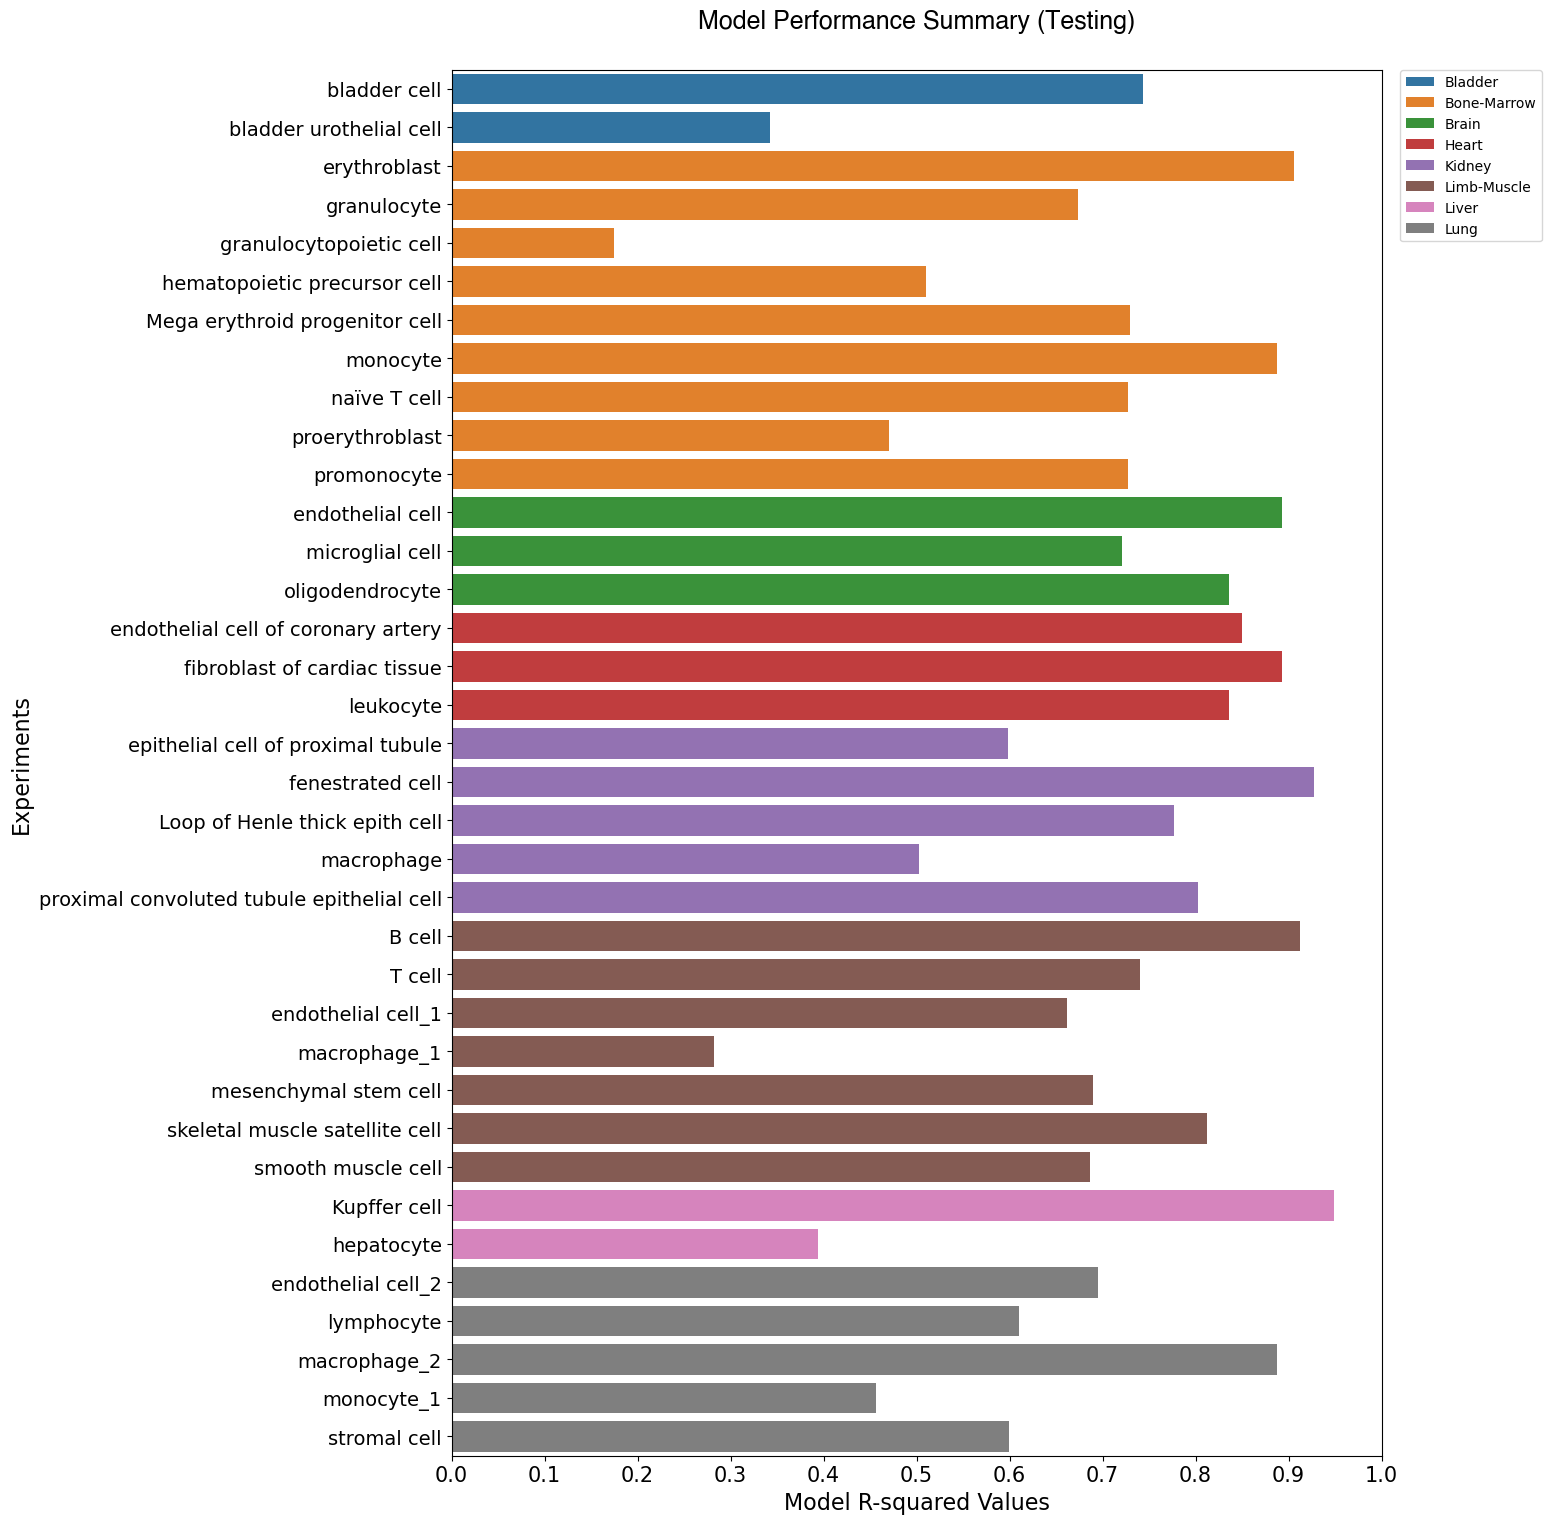

In [29]:
plt.figure(figsize=(12, 18))  # taller figure for many cell types

ax = sns.barplot(
    y=combined_df.index,                 # categories on y-axis
    x=combined_df["R_squared"],          # values on x-axis
    hue=combined_df["Experiment"],
    dodge=False
)

plt.xticks(np.arange(0, 1.1, 0.1), fontsize=15)
plt.yticks(fontsize=14)

plt.xlabel('Model R-squared Values', fontsize=16)
plt.ylabel('Experiments', fontsize=16)

plt.title(
    "Model Performance Summary (Testing)",
    fontsize=18,
    fontname="Helvetica",
    pad=30,
    fontweight="bold"
)

plt.legend(fontsize=15)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)

plt.savefig(
    "./Figures/Histogram_of_R-squared_by_Celltype.png",
    dpi=600,
    bbox_inches='tight'
)

plt.show()
plt.close()